In [73]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
file_path = r"C:/Users/Dalbir/Downloads/Trends-Forecasting-Analytics-MLOps-Vertex-AI/data/processed_file/sales_featured.parquet"
df = pd.read_parquet(file_path)

In [74]:
df.head()


,order_id,product,quantity_ordered,price_each,order_date,purchase_address,month,sales,city,hour,...,day,day_name,weekday_weekend,order_size,quarter,SMA_3,SMA_5,Lag_3,Lag_5,CMA
0,295665,Macbook Pro Laptop,1,1700.00,2019-12-30 00:01:00,"136 Church St, New York City, NY 10001",12,1700.00,New York City,0,...,1,Monday,Weekday,single,4,NaN,NaN,NaN,NaN,1700.000
1,295666,LG Washing Machine,1,600.00,2019-12-29 07:03:00,"562 2nd St, New York City, NY 10001",12,600.00,New York City,7,...,7,Sunday,Weekend,single,4,NaN,NaN,NaN,NaN,1150.000
2,295667,USB-C Charging Cable,1,11.95,2019-12-12 18:21:00,"277 Main St, New York City, NY 10001",12,11.95,New York City,18,...,4,Thursday,Weekday,single,4,770.650000,NaN,NaN,NaN,770.650
3,295668,27in FHD Monitor,1,149.99,2019-12-22 15:13:00,"410 6th St, San Francisco, CA 94016",12,149.99,San Francisco,15,...,7,Sunday,Weekend,single,4,253.980000,NaN,1700.0,NaN,615.485
4,295669,USB-C Charging Cable,1,11.95,2019-12-18 12:38:00,"43 Hill St, Atlanta, GA 30301",12,11.95,Atlanta,12,...,3,Wednesday,Weekday,single,4,57.963333,494.778,600.0,NaN,494.778


## Top Products by Sales

C:\Users\Dalbir\AppData\Local\Temp\ipykernel_12580\3637950017.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = top_products.values, y = top_products.index,palette="Set3")


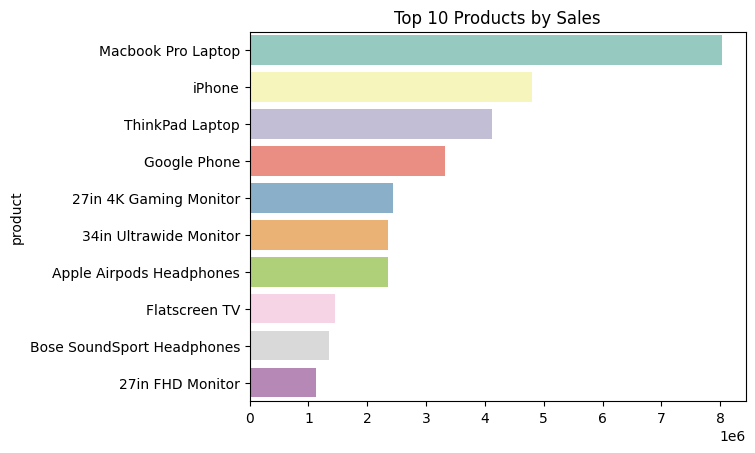

In [75]:
top_products = df.groupby("product")["sales"].sum().sort_values(ascending=False).head(10)
sns.barplot(x = top_products.values, y = top_products.index,palette="Set3")
plt.title("Top 10 Products by Sales")
plt.show()

## City Wise Monthly Sales

C:\Users\Dalbir\AppData\Local\Temp\ipykernel_12580\810834884.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  city_month_sales = df.groupby(["city","month"])["sales"].sum().reset_index()


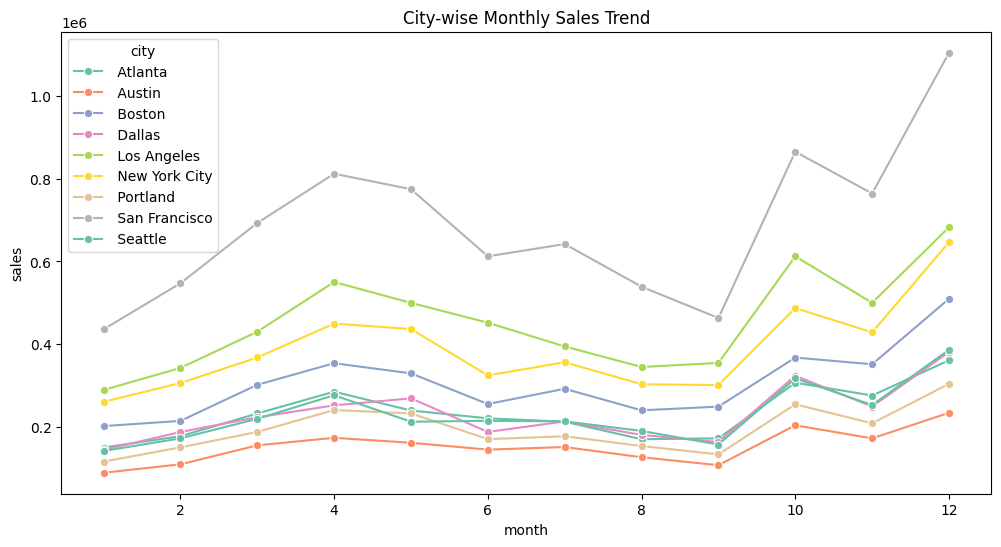

In [76]:
city_month_sales = df.groupby(["city","month"])["sales"].sum().reset_index()
plt.figure(figsize=(12,6))
sns.lineplot(x="month", y="sales", hue="city", data=city_month_sales, marker="o", palette="Set2")
plt.title("City-wise Monthly Sales Trend")
plt.show()


## Quarterly Sales Trend over years

C:\Users\Dalbir\AppData\Local\Temp\ipykernel_12580\1633029542.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


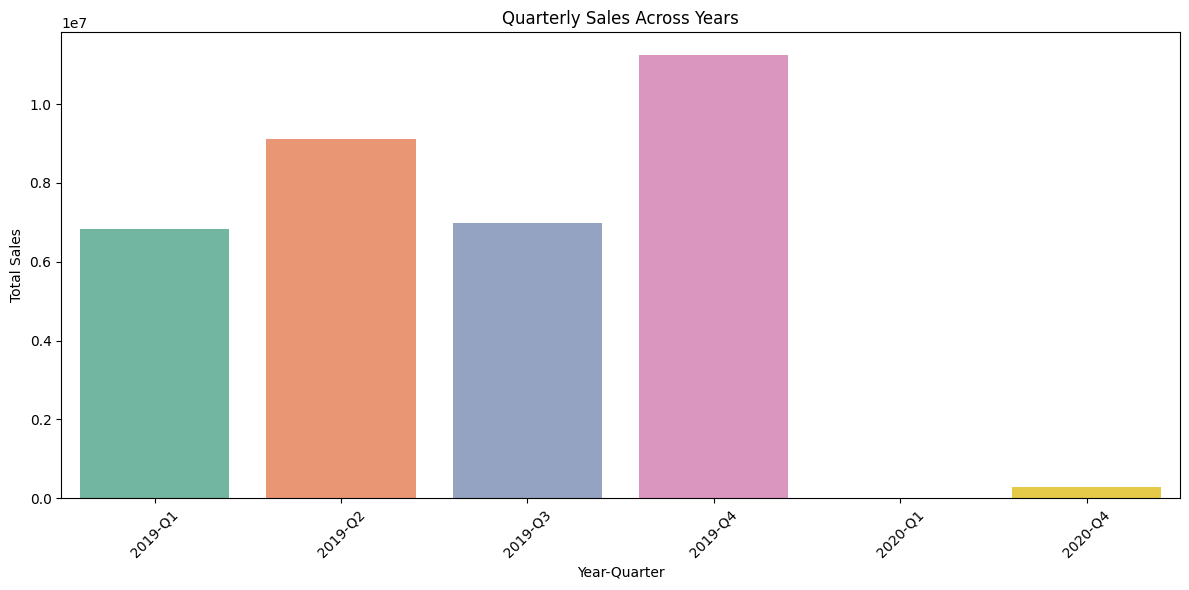

In [77]:
df["year_quarter"] = df["year"].astype(str) + "-Q" + df["quarter"].astype(str)
quarter_sales = df.groupby("year_quarter")["sales"].sum().reset_index()
plt.figure(figsize=(12,6))
sns.barplot(
    x="year_quarter", 
    y="sales", 
    data=quarter_sales, 
    palette="Set2"
)
plt.title("Quarterly Sales Across Years")
plt.xlabel("Year-Quarter")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Weekend vs Weekend Sales By City

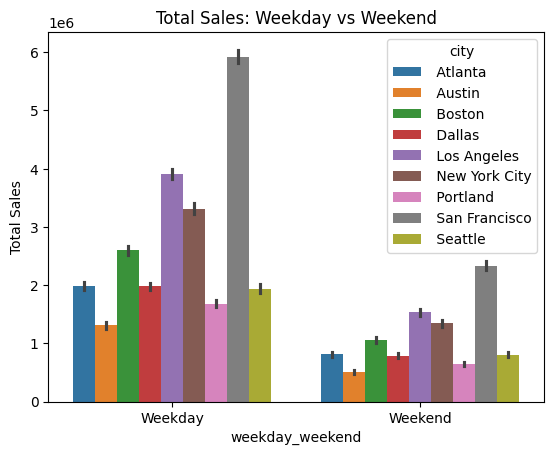

In [78]:
sns.barplot(x="weekday_weekend", y="sales",hue="city",data=df, estimator=sum)
plt.title("Total Sales: Weekday vs Weekend")
plt.ylabel("Total Sales")
plt.show()


## Weekly Sales

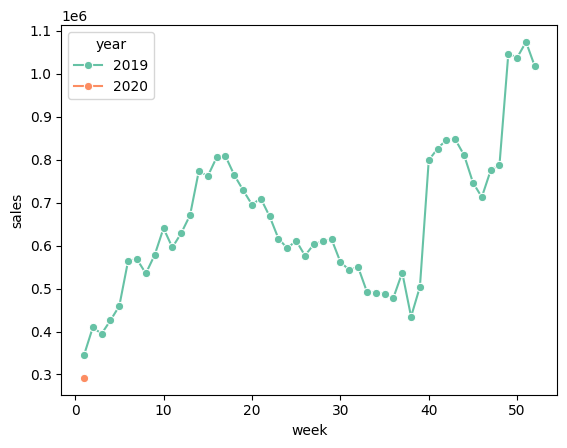

In [79]:
plt.figure()
sns.lineplot(x="week", y="sales", hue="year", data=df, estimator=sum, errorbar=None, marker="o",palette="Set2")
plt.show()

## Monthly Orders by City

C:\Users\Dalbir\AppData\Local\Temp\ipykernel_12580\878850008.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  city_orders = df.groupby("city")["quantity_ordered"].sum()


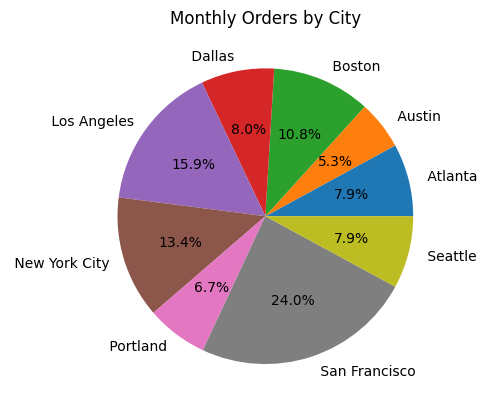

In [80]:
city_orders = df.groupby("city")["quantity_ordered"].sum()
plt.figure()
plt.pie(city_orders,labels= city_orders.index, data = df,autopct="%1.1f%%")
plt.title("Monthly Orders by City")
plt.show()

C:\Users\Dalbir\AppData\Local\Temp\ipykernel_12580\3610966957.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x="price_each", y="quantity_ordered", data=df, palette="Set2")


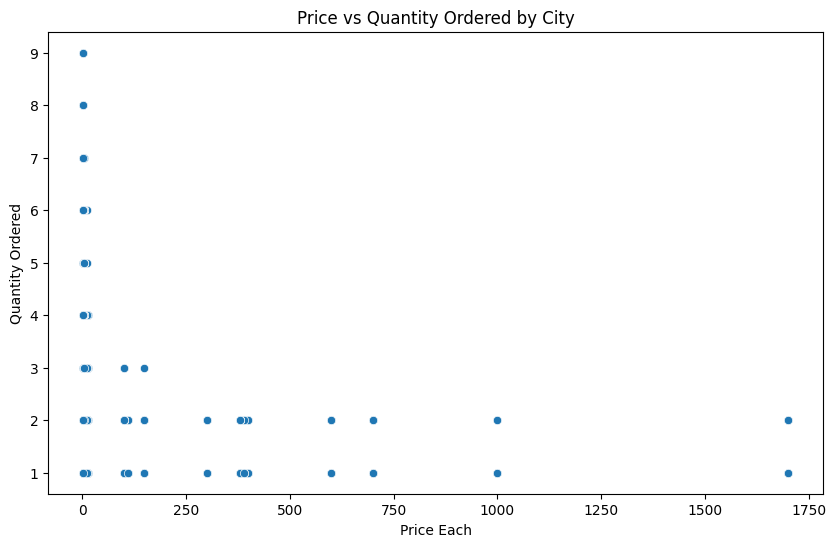

In [81]:
plt.figure(figsize=(10,6))
sns.scatterplot(x="price_each", y="quantity_ordered", data=df, palette="Set2")
plt.title("Price vs Quantity Ordered by City")
plt.xlabel("Price Each")
plt.ylabel("Quantity Ordered")
plt.show()

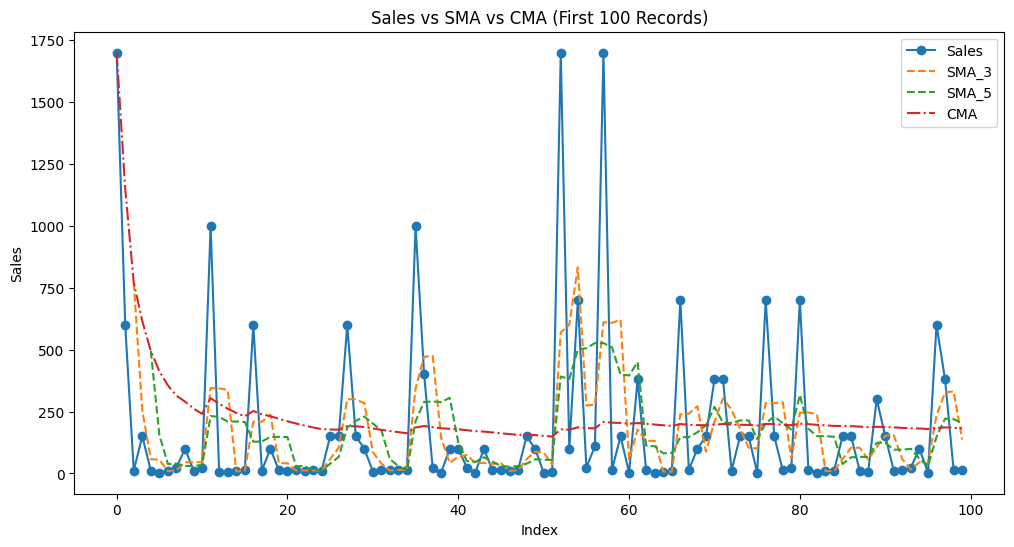

In [82]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(df["sales"].head(100), label="Sales", marker="o")
plt.plot(df["SMA_3"].head(100), label="SMA_3", linestyle="--")
plt.plot(df["SMA_5"].head(100), label="SMA_5", linestyle="--")
plt.plot(df["CMA"].head(100), label="CMA", linestyle="-.")

plt.title("Sales vs SMA vs CMA (First 100 Records)")
plt.xlabel("Index")
plt.ylabel("Sales")
plt.legend()
plt.show()
